# 🧠 Convolutional Neural Network (CNN) Implementation

In this notebook we implement a **Convolutional Neural Network (CNN)** using **PyTorch**.

The goal is to train a CNN model to classify images from the **CIFAR-10 dataset**.

This notebook demonstrates the complete deep learning workflow for image classification:

- loading image datasets
- preprocessing images
- building CNN architecture
- training the CNN model
- evaluating model performance


## 📊 Dataset: CIFAR-10

We use the **CIFAR-10 dataset**, a popular dataset for computer vision tasks.

Dataset details:

- **60,000 images**
- **32 × 32 color images**
- **10 classes**

Classes:

- airplane  
- automobile  
- bird  
- cat  
- deer  
- dog  
- frog  
- horse  
- ship  
- truck  

Each image has the shape:

**32 × 32 × 3**

## Step 1: Import Required Libraries

We import the required libraries for:

- deep learning (PyTorch)
- image datasets
- data preprocessing
- model evaluation

In [1]:
# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Torch vision for image datasets
import torchvision
import torchvision.transforms as transforms

# Visualization
import matplotlib.pyplot as plt

# Check device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## Step 2: Image Transformations

Images need to be converted into tensors and normalized before training.

Transformations applied:

- convert image → tensor
- normalize pixel values

In [2]:
# Image preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

## Step 3: Load Dataset

In [3]:
# Load training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100.0%
c:\Users\lakba\anaconda3\envs\ai-env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Step 4: Create Data Loaders

DataLoader helps load data in **batches**, which improves training efficiency.


In [4]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## Step 5: Define CNN Architecture

In [5]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


model = CNN().to(device)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


## Step 6: Define Loss Function and Optimizer

For classification tasks we use:

Loss Function

- CrossEntropyLoss

Optimizer

- Adam Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

## Step 7: Train the CNN

In [7]:
epochs = 10

train_losses = []

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")


Epoch [1/10] Loss: 1.3086
Epoch [2/10] Loss: 0.9091
Epoch [3/10] Loss: 0.7153
Epoch [4/10] Loss: 0.5471
Epoch [5/10] Loss: 0.3996
Epoch [6/10] Loss: 0.2570
Epoch [7/10] Loss: 0.1603
Epoch [8/10] Loss: 0.1006
Epoch [9/10] Loss: 0.0790
Epoch [10/10] Loss: 0.0701


## Step 8: Evaluate Model

In [8]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 72.23


## Step 9: Plot Training Loss

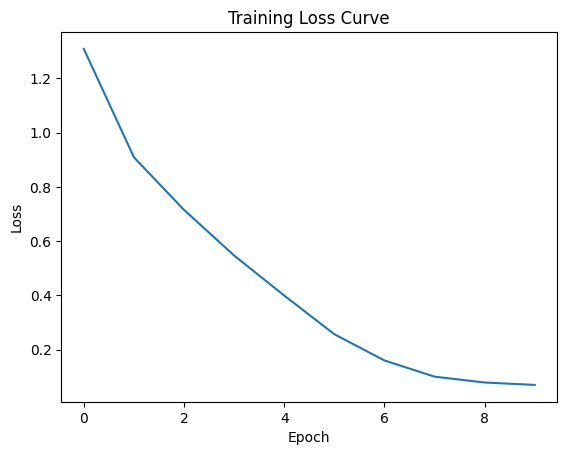

In [9]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## 🎯 Conclusion

In this notebook we implemented a **Convolutional Neural Network (CNN)** for image classification.

Key steps included:

- loading image datasets
- preprocessing images
- designing CNN architecture
- training the model
- evaluating classification accuracy

CNNs are powerful models that can automatically learn visual features such as edges, textures, and shapes from images.